# 01: Preprocessing

## Preliminares

In [1]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.functions import *

In [2]:
# Abrir ficheros
train_raw = pd.read_csv("data/train.csv")
test_raw = pd.read_csv("data/test.csv")

## Exploración y limpieza de datos

In [3]:
train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# Target: SalePrice
y_train = train_raw[["Id", "SalePrice"]]

In [5]:
y_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         1460 non-null   int64
 1   SalePrice  1460 non-null   int64
dtypes: int64(2)
memory usage: 22.9 KB


In [6]:
test_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [7]:
# Almacenar los Ids de test y la longitud del train para separar después
ids_test = test_raw['Id']
len_train = len(train_raw)

# Mergar train y test para preprocesar juntos
merged_df = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)

In [8]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   str    
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2919 non-null   str    
 8   LandContour    2919 non-null   str    
 9   Utilities      2917 non-null   str    
 10  LotConfig      2919 non-null   str    
 11  LandSlope      2919 non-null   str    
 12  Neighborhood   2919 non-null   str    
 13  Condition1     2919 non-null   str    
 14  Condition2     2919 non-null   str    
 15  BldgType       2919 non-null   str    
 16  HouseStyle     2919 non-null   str    
 17  OverallQual    2919 non-null   int64  
 18  OverallCond    2919

In [9]:
# Quitar Id y variable objetivo del dataset para preprocesar solo las features
merged_df.drop(["Id", "SalePrice"], axis = 1, inplace=True)

In [10]:
# Separar columnas numéricas y categóricas
# Valores únicos por columna numérica
merged_df.select_dtypes(np.number).nunique().sort_values()

HalfBath            3
BsmtHalfBath        3
KitchenAbvGr        4
BsmtFullBath        4
Fireplaces          5
FullBath            5
YrSold              5
GarageCars          6
BedroomAbvGr        8
OverallCond         9
OverallQual        10
MoSold             12
TotRmsAbvGrd       14
PoolArea           14
MSSubClass         16
3SsnPorch          31
LowQualFinSF       36
MiscVal            38
YearRemodAdd       61
GarageYrBlt       103
YearBuilt         118
ScreenPorch       121
LotFrontage       128
EnclosedPorch     183
OpenPorchSF       252
BsmtFinSF2        272
WoodDeckSF        379
MasVnrArea        444
GarageArea        603
2ndFlrSF          635
BsmtFinSF1        991
TotalBsmtSF      1058
1stFlrSF         1083
BsmtUnfSF        1135
GrLivArea        1292
LotArea          1951
dtype: int64

In [11]:
# Seleccionar columnas numéricas
num_cols = merged_df.select_dtypes(include=["int64", "float64"]).columns

#  Seleccionar columnas categóricas: aquellas que se han forzado a ser categóricas y aquellas numéricas con pocos valores únicos
forced_categoricals = ["MSSubClass"]
auto_categoricals = [col for col in num_cols if (merged_df[col].nunique() <= 12) and ('Yr' not in col)]

# Mergear ambas listas de columnas categóricas y convertirlas a tipo 'category'
categorical_cols = sorted(set(forced_categoricals + auto_categoricals))
merged_df[categorical_cols] = merged_df[categorical_cols].astype("category")

# Agregar a la lista de columnas categóricas aquellas que son de tipo 'object'
categorical_cols.extend(merged_df.select_dtypes("object").columns)

# Actualizar columnas numéricas
num_cols = merged_df.select_dtypes(include=["int64", "float64"]).columns
print(f"Número de columnas categóricas: {len(categorical_cols)}"
      f"\nNúmero de columnas numéricas: {len(num_cols)}")

Número de columnas categóricas: 55
Número de columnas numéricas: 24


C:\Users\sebas\AppData\Local\Temp\ipykernel_10560\634644643.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols.extend(merged_df.select_dtypes("object").columns)


Columnas numéricas:

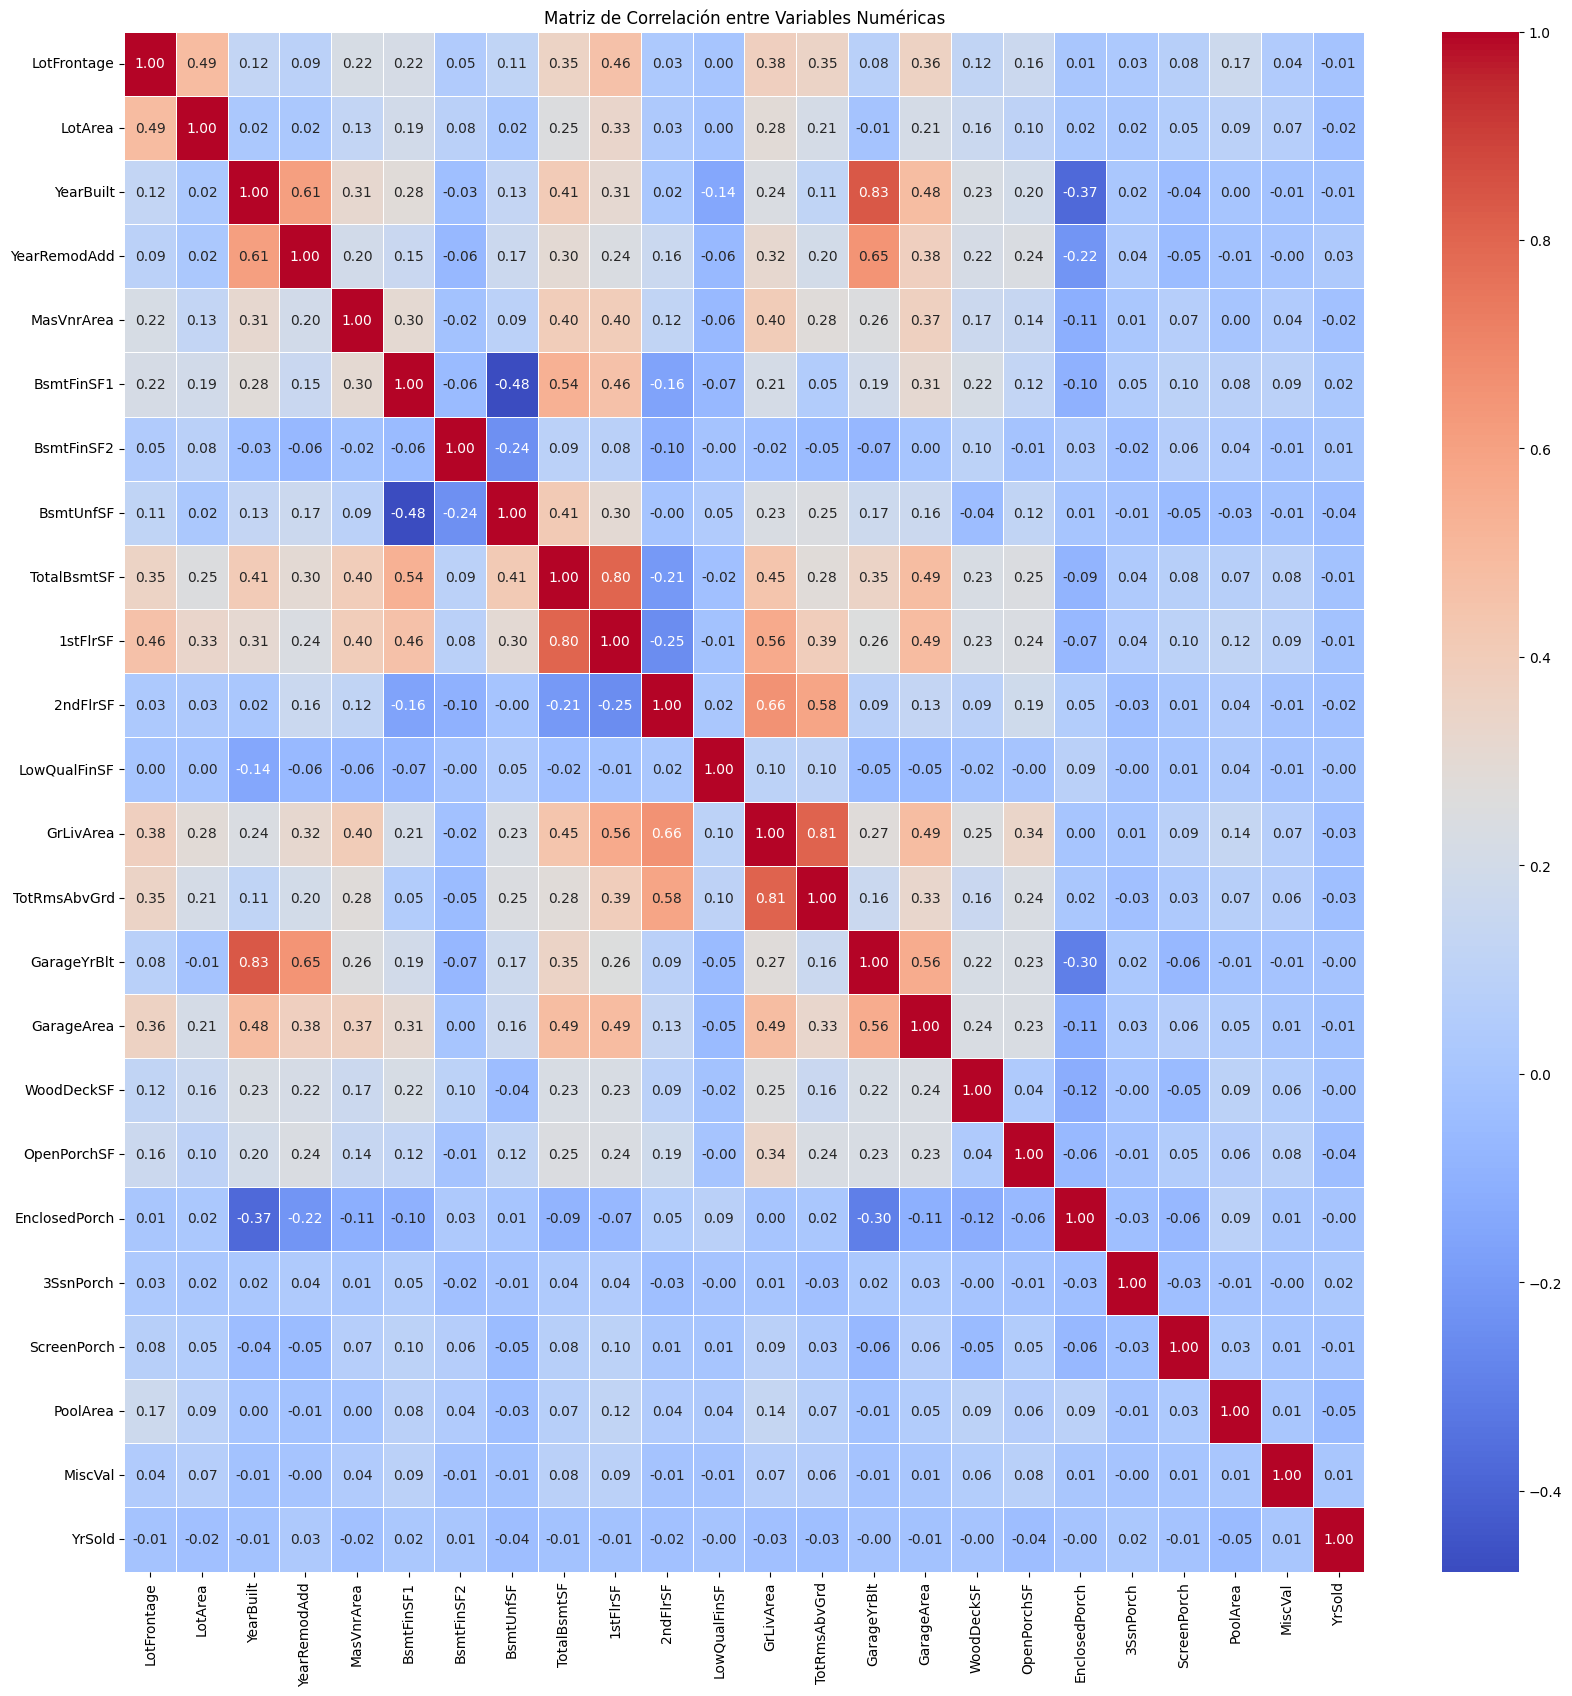

In [12]:
# Matriz de correlación entre variables numéricas
correlation_matrix = merged_df[num_cols].corr()
# Ampliar el tamaño de la figura para mejorar la legibilidad
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas")

plt.show()

In [13]:
merged_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LotFrontage,2433.0,69.305795,23.344905,21.0,59.0,68.0,80.0,313.0
LotArea,2919.0,10168.114080,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
YearBuilt,2919.0,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
MasVnrArea,2896.0,102.201312,179.334253,0.0,0.0,0.0,164.0,1600.0
BsmtFinSF1,2918.0,441.423235,455.610826,0.0,0.0,368.5,733.0,5644.0
BsmtFinSF2,2918.0,49.582248,169.205611,0.0,0.0,0.0,0.0,1526.0
BsmtUnfSF,2918.0,560.772104,439.543659,0.0,220.0,467.0,805.5,2336.0
TotalBsmtSF,2918.0,1051.777587,440.766258,0.0,793.0,989.5,1302.0,6110.0
1stFlrSF,2919.0,1159.581706,392.362079,334.0,876.0,1082.0,1387.5,5095.0


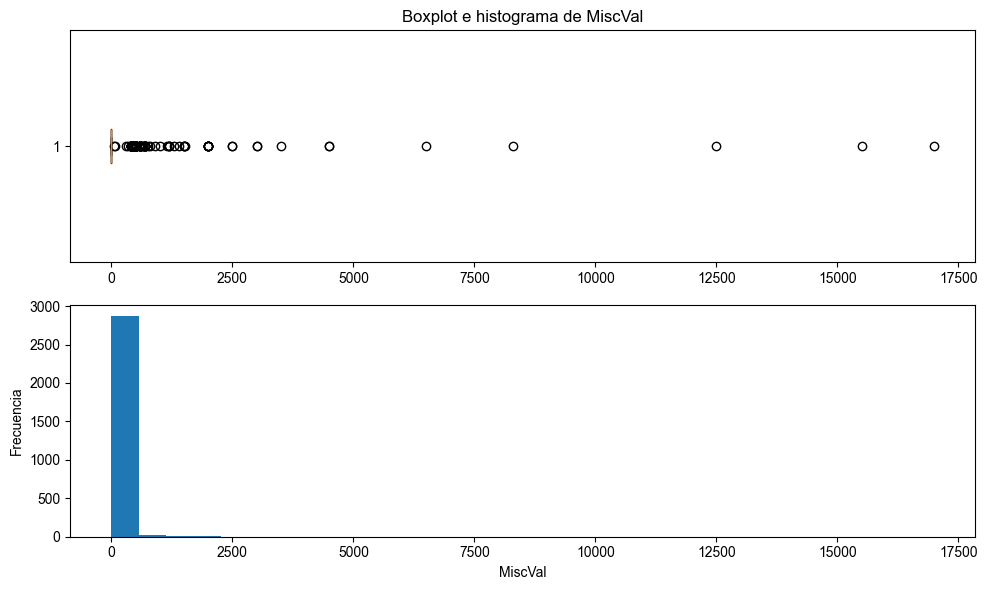

In [14]:
# Visualización de variables numéricas
variables_a_visualizar = ['MiscVal']
for variable in variables_a_visualizar:
    visualizar_variable(merged_df, variable, transformar=None)

* `LotFrontage`: Será reemplazada por la variable `LotDepthRatio` como el cociente de `LotArea` entre `LotFrontage` en la sección *Feature Engineering*.
Se imputan NaN por la mediana del vecindario (Neighborhood).
* `LotArea`: al aplicar transformación logarítmica la distribución se normaliza, pero permanece un gran número de *outliers*, tanto superiores como inferiores. Ya que se aplicarán modelos basados en árboles de decisión, estos outliers no serán tratados ya que dichos modelos son inmunes a los valores atípicos.
* `YearBuilt`: sin valores perdidos. Será reemplazada por la variable `HouseAge`.
* `YearRemodAdd` el pico en 1950 es un valor missing no declarado. Se asignan a NaN y se crea la variable `YearRemodAddIsMissing` para detectar si existen patrones en dichos valores perdidos. Los valores NaN luego son imputados con el valor de `YearBuilt`, ya que si la casa no fue remodelada entonces el año de remodelación coincide con el año de construcción. Será reemplazada por la variable `RemodelAge`.
* `MasVnrArea`: valores en cero son casas que no tienen revestimento de mampostería en la fachada. Interactua con la variable `MasVnrType`. Se imputan missings como cero.

Variables de sótano:
* `BsmtFinSF1`: Área terminada del sótano, tipo 1 (pies cuadrados)
* `BsmtFinSF2`: Área terminada del sótano, tipo 2 (pies cuadrados)
* `BsmtUnfSF`: Área no terminada del sótano (pies cuadrados)
* `TotalBsmtSF`: Área total del sótano (pies cuadrados)

Se reemplazarán las 3 primeras por una variable `RatioBsmt` como el porcentaje del sótano que está terminado, manteniendo `TotalBsmtSF`.

Variables de plantas:
* `1stFlrSF` y  `2ndFlrSF`: estan correlacionadas con el tamaño total `GrLivArea`.
* `LowQualFinSF`: es una variable rara, mayormente cero. Se elimina del dataset.
* `GrLivArea`

Se reemplazan las primeras por la variable `has_second_floor`, manteniendo `GrLivArea`. 

* `TotRmsAbvGrd`: tiene alta correlación con `GrLivArea`. Se reemplaza por `AvgRoomSize`.

Variables de Garage:
* `GarageYrBlt`: se imputan missings con el valor de `YearBuilt`, y se reemplazará por `GarageAge`.
* `GarageArea`: esta relacionada con capacidad del Garage `GarageCars`. Se imputan missings por cero, se reemplazara por la variable binaria `HasGarage`.


* `WoodDeckSF`: se imputan missings con cero. Se crea variable `HasWoodDeck`.

Variables de Porch:

* `OpenPorchSF`
* `EnclosedPorch`
* `3SsnPorch`
* `ScreenPorch`
Se creará la variable `TotalPorchSF` como la suma de las áreas anteriores, y `HasPorch` como variable binaria, capturando el beneficio extra de poseer cualquier tipo de Porch.

* `PoolArea`: se crea la variable `HasPool`.

* `MiscVal`: tiene muchos valores en cero. Se reemplaza por la variable binaria `HasMiscFeature`.


 

In [15]:
imputar_por_mediana = ['LotFrontage', 'LotArea']
merged_df.loc[merged_df['YearRemodAdd'] == 1950, 'YearRemodAdd'] = np.nan
merged_df['YearRemodAddIsMissing'] = merged_df['YearRemodAdd'].isna().astype(int)
imputar_por_cero = ['MasVnrArea']
imputar_por_cero.extend(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF'])
imputar_por_cero.extend(['1stFlrSF', '2ndFlrSF', 'GrLivArea'])
merged_df.drop(['LowQualFinSF'], axis=1, inplace=True)
imputar_por_cero.extend(['GarageArea'])
imputar_por_cero.extend(['WoodDeckSF'])
imputar_por_cero.extend(['OpenPorchSF'])

# Actualizar columnas numéricas
num_cols = merged_df.select_dtypes(include=["int64", "float64"]).columns


In [16]:
merged_df[num_cols].skew().sort_values()

YearRemodAdd             -0.665182
YearBuilt                -0.600114
GarageYrBlt              -0.382150
YrSold                    0.132467
GarageArea                0.241301
TotRmsAbvGrd              0.758757
2ndFlrSF                  0.862118
BsmtUnfSF                 0.919824
TotalBsmtSF               1.162882
GrLivArea                 1.270010
BsmtFinSF1                1.425722
1stFlrSF                  1.470360
LotFrontage               1.503278
WoodDeckSF                1.843380
YearRemodAddIsMissing     2.287439
OpenPorchSF               2.536417
MasVnrArea                2.602589
ScreenPorch               3.948723
EnclosedPorch             4.005950
BsmtFinSF2                4.147456
3SsnPorch                11.381914
LotArea                  12.829025
PoolArea                 16.907017
MiscVal                  21.958480
dtype: float64

## Imputar missings

In [17]:
# Incidencia de missings en numéricas
merged_df[num_cols].apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)


LotFrontage              0.166495
YearRemodAdd             0.123672
GarageYrBlt              0.054471
MasVnrArea               0.007879
BsmtFinSF2               0.000343
BsmtUnfSF                0.000343
TotalBsmtSF              0.000343
BsmtFinSF1               0.000343
GarageArea               0.000343
YearBuilt                0.000000
LotArea                  0.000000
1stFlrSF                 0.000000
GrLivArea                0.000000
2ndFlrSF                 0.000000
TotRmsAbvGrd             0.000000
WoodDeckSF               0.000000
OpenPorchSF              0.000000
EnclosedPorch            0.000000
3SsnPorch                0.000000
ScreenPorch              0.000000
PoolArea                 0.000000
MiscVal                  0.000000
YrSold                   0.000000
YearRemodAddIsMissing    0.000000
dtype: float64

In [18]:
# Imputar por cero
for variable in imputar_por_cero:
    merged_df[variable] = merged_df[variable].replace(np.nan, 0)

# Imputar por la mediana del vecindario
for columna in imputar_por_mediana:
    imputar_por_grupo(merged_df, columna, 'Neighborhood', metodo= 'median')

# Imputar NaN en YearRemodAdd y GarageYrBlt por el valor de YearBuilt
merged_df['YearRemodAdd'] = merged_df['YearRemodAdd'].fillna(merged_df['YearBuilt'])
merged_df['GarageYrBlt'] = merged_df['GarageYrBlt'].fillna(merged_df['YearBuilt'])

In [19]:
# Incidencia de missings en categóricas
merged_df[categorical_cols].apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

PoolQC           0.996574
MiscFeature      0.964029
Alley            0.932169
Fence            0.804385
MasVnrType       0.605002
FireplaceQu      0.486468
GarageCond       0.054471
GarageQual       0.054471
GarageFinish     0.054471
GarageType       0.053786
BsmtCond         0.028092
BsmtExposure     0.028092
BsmtQual         0.027749
BsmtFinType2     0.027407
BsmtFinType1     0.027064
MSZoning         0.001370
Functional       0.000685
BsmtHalfBath     0.000685
BsmtFullBath     0.000685
Utilities        0.000685
Exterior2nd      0.000343
GarageCars       0.000343
Exterior1st      0.000343
KitchenQual      0.000343
SaleType         0.000343
Electrical       0.000343
Condition2       0.000000
LotConfig        0.000000
LandContour      0.000000
LotShape         0.000000
Street           0.000000
MSSubClass       0.000000
OverallQual      0.000000
MoSold           0.000000
OverallCond      0.000000
KitchenAbvGr     0.000000
Fireplaces       0.000000
FullBath         0.000000
HalfBath    

In [20]:
# Se imputan por la moda del vecindario
for columna in categorical_cols:
    imputar_por_grupo(merged_df, columna, 'Neighborhood', metodo= 'mode')

## Feature Engineering

In [21]:
# Crear variables HouseAge y RemodelAge, eliminando luego las variables originales
merged_df['HouseAge'] = merged_df['YrSold'] - merged_df['YearBuilt']
merged_df['RemodelAge'] = merged_df['YrSold'] - merged_df['YearRemodAdd']
merged_df.drop(['YearBuilt', 'YearRemodAdd'], axis=1, inplace=True)

# Crear variable RatioBsmt y se eliminan las variables originales de sótano
finished_area = merged_df['BsmtFinSF1'] + merged_df['BsmtFinSF2']
merged_df['RatioBsmt'] = np.where(merged_df['TotalBsmtSF'] != 0, finished_area / merged_df['TotalBsmtSF'], 0)
merged_df.drop(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'], axis=1, inplace=True)

# Crear HasSecondFloor y Se eliminan las variables originales de área
merged_df['HasSecondFloor'] = (merged_df['2ndFlrSF'] > 0).astype(int)
merged_df.drop(['1stFlrSF', '2ndFlrSF'], axis=1, inplace=True)

# Crear AvgRoomSize y eliminar TotRmsAbvGrd
merged_df['AvgRoomSize'] = merged_df['GrLivArea'] / merged_df['TotRmsAbvGrd']
merged_df.drop(['TotRmsAbvGrd'], axis=1, inplace=True)

# Crear HasGarage y eliminar la columna original
merged_df['HasGarage'] = (merged_df['GarageArea'] > 0).astype(int)
merged_df.drop(['GarageArea'], axis=1, inplace=True)

# Crear GarageAge y eliminar la columna original
merged_df['GarageAge'] = merged_df['YrSold'] - merged_df['GarageYrBlt']
# Si no tiene garaje, su "edad de garaje" se vuelve 0
merged_df.loc[merged_df['HasGarage'] == 0, 'GarageAge'] = 0
merged_df.drop(['GarageYrBlt'], axis=1, inplace=True)

# Crear HasWoodDeck
merged_df['HasWoodDeck'] = (merged_df['WoodDeckSF'] > 0).astype(int)

# Crear TotalPorchSF, HasPorch y eliminar las columnas originales
merged_df['TotalPorchSF'] = (merged_df['OpenPorchSF'] + merged_df['EnclosedPorch'] + merged_df['3SsnPorch'] + merged_df['ScreenPorch'])
merged_df['HasPorch'] = (merged_df['TotalPorchSF'] > 0).astype(int)
merged_df.drop(['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'], axis=1, inplace=True)

# Crear HasMiscFeature y eliminar la columna original
merged_df['HasMiscFeature'] = (merged_df['MiscVal']>0).astype(int)
merged_df.drop(['MiscVal'], axis =1, inplace=True)



In [22]:
# Se guardan los resultados en fichero merged_df_clean
merged_df.to_csv('data/merged_df_clean.csv', index=False)